# Prédiction de précipitation à partir de données météo
Ce notebook illustre le prétraitement, la modélisation et l'évaluation de modèles ML sur un dataset météo synthétique.

In [1]:
# 📦 Importations
import pandas as pd
import sys
from pathlib import Path

# Extention du chemin
sys.path.append('../src')
sys.path.append('../data')
sys.path.append('../utils')

# Importation des fonctions
from sklearn.preprocessing import StandardScaler
from preprocessing import load_data, preprocess_data
from evaluation import evaluate_model
from models import get_models, get_specific_models
from visualisation import plot_correlation, plot_predictions

In [2]:
# 📥 Chargement des données
df = load_data('../data/meteo.csv')
df.head()

,datetime,temperature,humidity,pressure,wind_speed,precipitation
0,2021-01-01 00:00:00,19.967142,40.048955,1009.907909,7.690012,0
1,2021-01-01 01:00:00,13.617357,36.274070,1005.478436,6.111650,0
2,2021-01-01 02:00:00,21.476885,68.185815,1016.191745,8.631638,0
3,2021-01-01 03:00:00,30.230299,72.388544,1026.404504,10.544280,0
4,2021-01-01 04:00:00,12.658466,31.895169,994.248275,11.785088,1


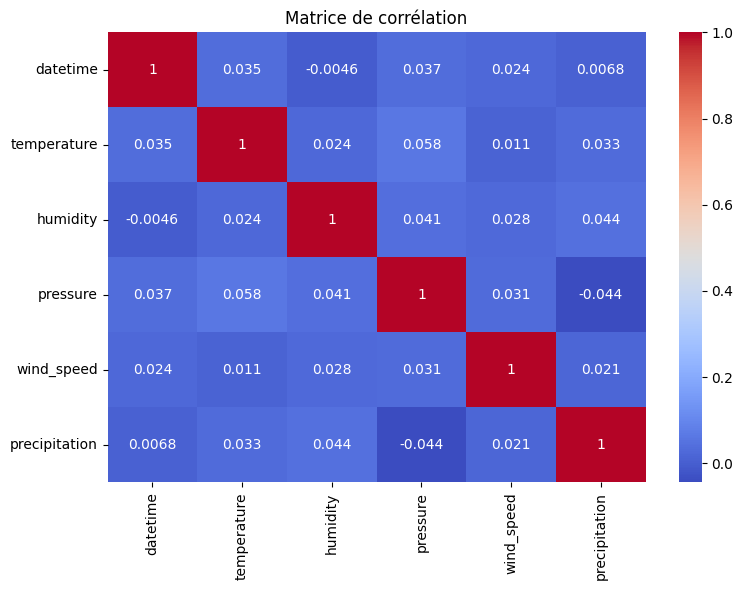

In [3]:
# 📊 Visualisation des corrélations
plot_correlation(df)

In [4]:
# ⚙️ Prétraitement des données
X_train, X_test, y_train, y_test = preprocess_data(df)

# Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Définition d'une fonction de choix de modèle

In [5]:
def compare_regression_models(models, X_train, X_test, y_train, y_test):
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        print(f"\n📌 Évaluation du modèle : {name}")
        metrics = evaluate_model(model, X_test, y_test)
        metrics["Model"] = name
        results.append(metrics)

    results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

    best_model = results_df.iloc[0]
    print(f"\n🏆 Meilleur modèle : {best_model['Model']} avec un R² de {best_model['R2']:.4f}")
    return results_df

In [6]:
# 🤖 Chargement des modèles
all_models = get_models()

result_df = compare_regression_models(all_models,X_train,X_test,y_train,y_test)
print(result_df['model'][0])


📌 Évaluation du modèle : KNN
Accuracy: 0.755
🔢 MAE : 0.2450
📉 MSE : 0.2450
📈 RMSE : 0.4950
📊 R² : -0.8229

📌 Évaluation du modèle : Logistic Regression
Accuracy: 0.84
🔢 MAE : 0.1600
📉 MSE : 0.1600
📈 RMSE : 0.4000
📊 R² : -0.1905

📌 Évaluation du modèle : Decision Tree
Accuracy: 0.575
🔢 MAE : 0.4250
📉 MSE : 0.4250
📈 RMSE : 0.6519
📊 R² : -2.1622

📌 Évaluation du modèle : Random Forest
Accuracy: 0.77
🔢 MAE : 0.2300
📉 MSE : 0.2300
📈 RMSE : 0.4796
📊 R² : -0.7113

🏆 Meilleur modèle : Logistic Regression avec un R² de -0.1905
KNeighborsClassifier()


In [8]:
# Définition des prédictions du modèle
y_pred = get_specific_models(0).predict(X_test_scaled)

# Affichage des comparaisons entre les données prédites et réelles
plot_predictions(y_train,y_pred)

NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

## Évaluation des modèles de régression

Nous avons testé plusieurs modèles sur notre jeu de données météorologiques. Pour comparer leurs performances, nous nous sommes basés principalement sur :

- **R² (coefficient de détermination)** : mesure la proportion de variance expliquée par le modèle. Plus il est proche de 1, meilleur est le modèle.
- **RMSE (Root Mean Squared Error)** : pénalise fortement les grandes erreurs. Plus il est bas, plus la prédiction est proche des valeurs réelles.
- **MAE (Mean Absolute Error)** : mesure moyenne des erreurs absolues, plus robuste que le MSE face aux valeurs extrêmes.

### Sélection
Nous avons sélectionné le modèle avec le **meilleur score R²** comme le plus performant pour cette tâche. En effet, R² reflète la capacité du modèle à généraliser sur des données non vues, ce qui est crucial pour la prédiction météo.
